# Lab 3 — Visualization notebook

**This notebook is a working tool, not a deliverable — you do NOT submit it.**

It contains no logic of its own: it imports your finished functions from `../src/lab03.py`
and plots their output. If a cell below fails, the bug is in your `.py`, not in the plot.

Your job: complete the three plot cells, then **export each figure and paste it into
`report.pdf`** (right-click → Save image as…, or `plt.savefig('fig1.png', dpi=150)`).
Figures 1–3 are required by the report template.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import lab03

data = lab03.load_data('../data/lab03_scene.npz')
X, labels_true = data['X'], data['labels']

rng = np.random.default_rng(lab03.SEED)
centers, km_labels, inertia = lab03.kmeans(X, lab03.K_OBJECTS, rng)      # Task 1
means, covs, weights, resp, lls = lab03.gmm_em(X, lab03.K_OBJECTS, rng)  # Task 2
gmm_labels = resp.argmax(axis=1)
print(f'{len(X)} pts, k-means inertia {inertia:.2f}, '
      f'ARI k-means {lab03.adjusted_rand_index(labels_true, km_labels):.4f}, '
      f'ARI GMM {lab03.adjusted_rand_index(labels_true, gmm_labels):.4f}')

1614 pts, k-means inertia 281.81, ARI k-means 0.6082, ARI GMM 0.9104


## Plot 1 — Report Figure 1: the scene, K-means vs GMM labels

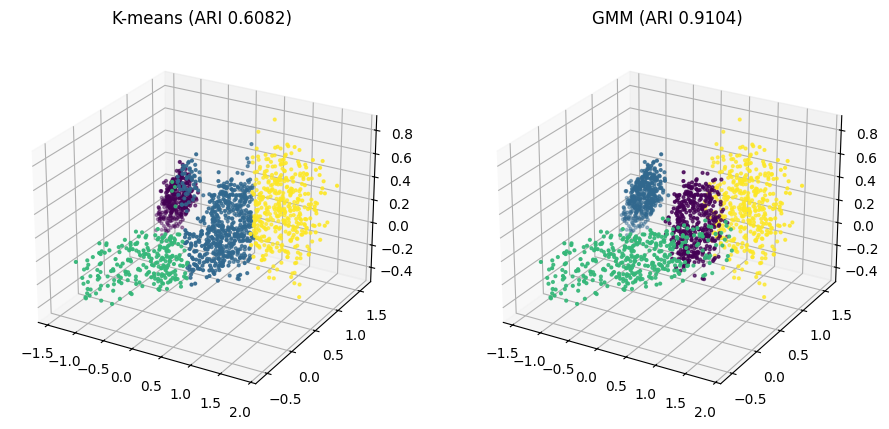

In [2]:
fig = plt.figure(figsize=(11, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=km_labels, s=4)
ax.view_init(elev=25, azim=-60)
ax.set_title(f'K-means (ARI {lab03.adjusted_rand_index(labels_true, km_labels):.4f})')

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=gmm_labels, s=4)
ax.view_init(elev=25, azim=-60)
ax.set_title(f'GMM (ARI {lab03.adjusted_rand_index(labels_true, gmm_labels):.4f})')

plt.savefig('fig1.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — Report Figure 2: the EM log-likelihood trace

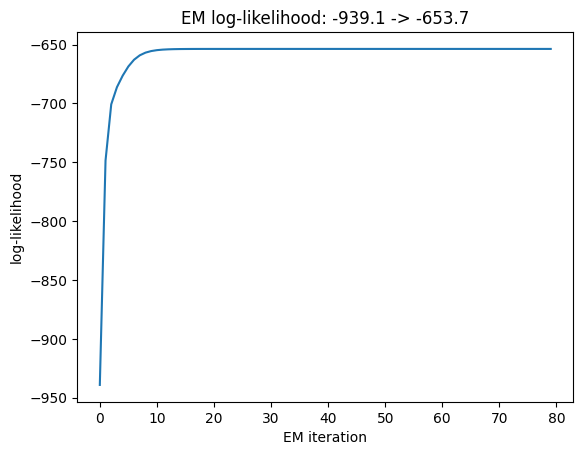

In [3]:
plt.plot(lls)
plt.xlabel('EM iteration')
plt.ylabel('log-likelihood')
plt.title(f'EM log-likelihood: {lls[0]:.1f} -> {lls[-1]:.1f}')
plt.savefig('fig2.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — Report Figure 3: the BIC curve

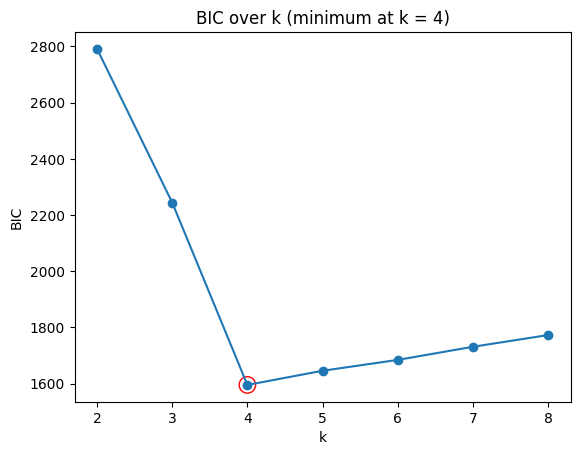

In [4]:
bics, best_k = lab03.select_k(X, lab03.K_RANGE, rng)
plt.plot(lab03.K_RANGE, bics, marker='o')
plt.scatter([best_k], [min(bics)], s=140, facecolors='none', edgecolors='red')
plt.xlabel('k')
plt.ylabel('BIC')
plt.title(f'BIC over k (minimum at k = {best_k})')
plt.savefig('fig3.png', dpi=150, bbox_inches='tight')
plt.show()